<h1> Análise Exploratória de Dados </h1>
Objetivo: Continuar a compreensão das bases de dados existentes de clientes, interações focando principalmente na análise bilateral. 
Entrada: Base de dados de cliente tratada (sem valores nulos), interações
Saída: Relatório detalhadado descobrindo diversos insights e versão preliminar para a construção da ABT. Exemplo: </br> 
1 - Em relação ao porte da empresa, como está a regularização dentro dos próximos 30 dias? </br>
2 - Qual a média do tempo de relacionamento das empresas que regularizaram ou não dentro dos próximos 30 dias </br>
Outros insights  poderão ser explorados durante o estudo.

<h3> Importação de pacotes e bibliotecas </h3>

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from matplotlib.ticker import FuncFormatter
#from ydata_profiling import ProfileReport
# import loguru # Configuracao de login da plataforma

<h3> Definição de Métodos e Funções </h3>

In [2]:
def gerar_bar_plot_percentual(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(12, 6))

    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.bar(x, y, color=cores)

    for bar, valor in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{valor:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_ylim(0, 100)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [3]:
def plot_barras_duplas(
    df,
    coluna_categoria,
    coluna_valor_1,
    coluna_valor_2,
    nome_valor_1='Grupo 1',
    nome_valor_2='Grupo 2',
    titulo='Comparação',
    ylabel='Percentual (%)',
    figsize=(12, 6),
    rotacao_x=45
):
    """
    Plota gráfico de barras duplas agrupadas.

    Parâmetros:
    ----------
    df : DataFrame
        DataFrame contendo as categorias e os dois valores.

    coluna_categoria : str
        Coluna usada no eixo X.

    coluna_valor_1 : str
        Coluna com os valores da primeira barra.

    coluna_valor_2 : str
        Coluna com os valores da segunda barra.

    nome_valor_1 : str
        Nome exibido na legenda para a primeira barra.

    nome_valor_2 : str
        Nome exibido na legenda para a segunda barra.

    titulo : str
        Título do gráfico.

    ylabel : str
        Nome do eixo Y.

    figsize : tuple
        Tamanho da figura.

    rotacao_x : int
        Rotação dos rótulos do eixo X.
    """

    x = range(len(df))
    largura = 0.4

    fig, ax = plt.subplots(figsize=figsize)

    barras_1 = ax.bar(
        [i - largura / 2 for i in x],
        df[coluna_valor_1],
        width=largura,
        label=nome_valor_1
    )

    barras_2 = ax.bar(
        [i + largura / 2 for i in x],
        df[coluna_valor_2],
        width=largura,
        label=nome_valor_2
    )

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(coluna_categoria)
    ax.set_ylabel(ylabel)

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        df[coluna_categoria],
        rotation=rotacao_x,
        ha='right'
    )

    ax.legend()

    # Valores sobre as barras
    ax.bar_label(
        barras_1,
        fmt='%.1f%%',
        padding=3
    )

    ax.bar_label(
        barras_2,
        fmt='%.1f%%',
        padding=3
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [4]:
def gerar_barh_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.barh(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return (
            f'{valor:,.0f}'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.')
        )

    ax.xaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Percentual sobre o total
    total = y.sum()

    for bar, valor in zip(bars, y):
        percentual = valor / total * 100

        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {formato_brasileiro(valor)} ({percentual:.1f}%)',
            ha='left',
            va='center',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [5]:
def gerar_bar_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.bar(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

    ax.yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Valor absoluto sobre cada barra
    for bar, valor in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            formato_brasileiro(valor),
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [6]:
def gerar_relatorio_analitico_yprofiling(base,titulo,arq_html_salvar):
    try:
        profile = ProfileReport(
            base,
            title=titulo,
            explorative=True
        )
        profile.to_file(arq_html_salvar)
    except Exception as excecao:
        print(f"Erro ao gerar o relatório {excecao}")
    else:
        print(f"Relatório gerado com sucesso!")

In [7]:
def ler_base_por_csv(caminho_arquivo):
    """
    Lê um arquivo CSV e retorna um DataFrame do Pandas.
    """
    try:
        base_dataframe = pd.read_csv(caminho_arquivo)
        print(f"Arquivo lido com sucesso")
        return base_dataframe
    except Exception as excecao:
        print(f"Erro ao ler o arquivo: {excecao}")
        return None

In [8]:
def gerar_grafico_pizza(sizes,labels,titulo):
    colors = plt.cm.Blues(np.linspace(0.3, 0.7, len(sizes)))
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title(titulo)
    plt.show()

In [9]:
def gerar_histograma(
    dados,
    titulo,
    xlabel,
    ylabel,
    bins_qtde=10
):
    # Remover valores nulos
    dados = dados.dropna()

    # Média e desvio padrão
    media = dados.mean()
    desvio_padrao = dados.std()

    # Paleta de cores
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.8, bins_qtde)
    )

    # Criando a figura
    plt.figure(figsize=(8, 6))

    # Histograma
    n, bins, patches = plt.hist(
        dados,
        bins=bins_qtde,
        edgecolor="black",
        density=True
    )

    # Aplicando cores às barras
    for i, patch in enumerate(patches):
        patch.set_facecolor(colors[i])

    # -----------------------------
    # Curva de distribuição normal
    # -----------------------------

    x = np.linspace(
        dados.min(),
        dados.max(),
        1000
    )

    curva_normal = norm.pdf(
        x,
        media,
        desvio_padrao
    )

    plt.plot(
        x,
        curva_normal,
        linewidth=2,
        label=f"Distribuição Normal\nMédia = {media:,.0f}"
    )

    # Título e rótulos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Legenda
    plt.legend()

    # Remover notação científica
    plt.ticklabel_format(
        style="plain",
        axis="x",
        useOffset=False
    )

    plt.tight_layout()
    plt.show()

In [10]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Formatação brasileira dos valores
    def formato_brasileiro(valor, pos):
        return f"{valor:,.0f}".replace(",", ".")

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
def gerar_grafico_linhas(eixo_tempo, eixo_valores,title,xlabel,ylabel):    
    # Gerando o gráfico de linha
    plt.figure(figsize=(10, 6))
    plt.plot(eixo_tempo, eixo_valores, marker='o', linestyle='-', color='b')

    # Adicionando título e rótulos aos eixos
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.fill_between(eixo_tempo, eixo_valores, color='skyblue', alpha=0.4)

    # Exibindo o gráfico
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Remover notação científica do eixo Y
    plt.ticklabel_format(
        style="plain",
        axis="y",
        useOffset=False
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

<h3> Definição do Escopo Principal(Main) </h3>

<h3> Base de Clientes Tratada </h3>

VARÍAVEL [TARGET] x [CATEGÓRICAS]

<h4> 1. Relembrando a TARGET. Como está a distribuição dos clientes que regularizaram dentro dos 30 dias? Variável categórica nominal. </h4>

In [13]:
# Carregando a base de dados
caminho_base__clientes = "../bases_tratadas/clientes_sem_nulos.csv"
clientes_sem_nulos = ler_base_por_csv(caminho_base__clientes)
print(f"Qtde de linhas: {len(clientes_sem_nulos)}")
print(f"Qtde de colunas: {len(clientes_sem_nulos.columns)}")
print(f"Colunas: {clientes_sem_nulos.columns}")

Arquivo lido com sucesso
Qtde de linhas: 800
Qtde de colunas: 26
Colunas: Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')


In [14]:
print(f"Existem atualmmente {len(clientes_sem_nulos)} registros na base de clientes")
print(f"Existem atualmmente {len(clientes_sem_nulos['id_cliente'].unique())} clientes únicos na base dado id_cliente")
print(f"Percentual de registros duplicados: {round((len(clientes_sem_nulos) - len(clientes_sem_nulos['id_cliente'].unique())) / len(clientes_sem_nulos) * 100, 2)}%")

Existem atualmmente 800 registros na base de clientes
Existem atualmmente 800 clientes únicos na base dado id_cliente
Percentual de registros duplicados: 0.0%


In [15]:
resultado_target = (
    clientes_sem_nulos.groupby('regularizou_30d')
    .size()
    .reset_index(name='qtd_clientes')
)

resultado_target['percentual'] = (
    resultado_target['qtd_clientes']
    / resultado_target['qtd_clientes'].sum()
    * 100
)

resultado_target

,regularizou_30d,qtd_clientes,percentual
0,0,401,50.125
1,1,399,49.875


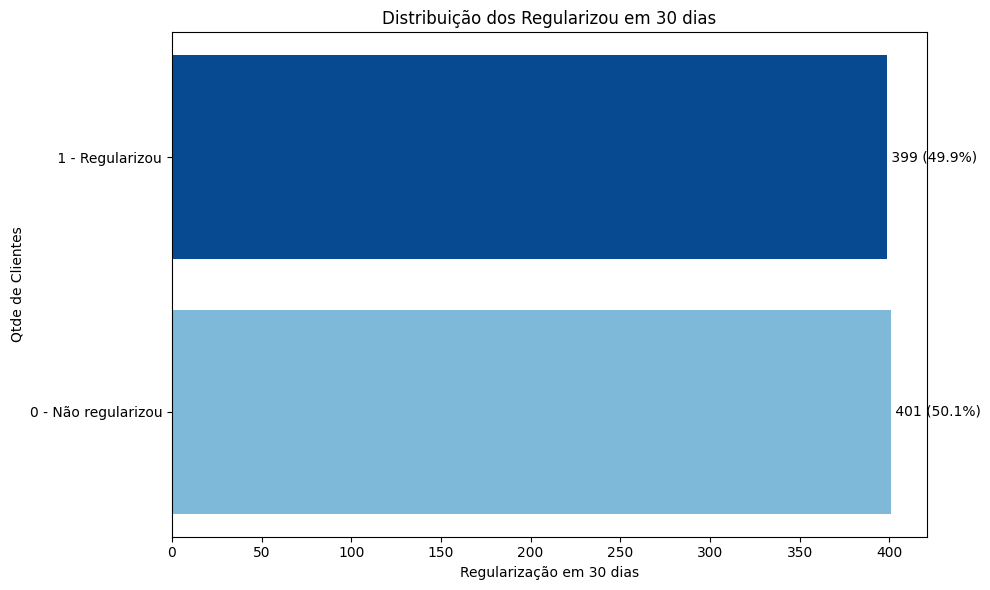

In [16]:
gerar_barh_plot(['0 - Não regularizou',' 1 - Regularizou'],
               resultado_target.qtd_clientes,
               "Distribuição dos Regularizou em 30 dias",
               "Regularização em 30 dias",
               "Qtde de Clientes")

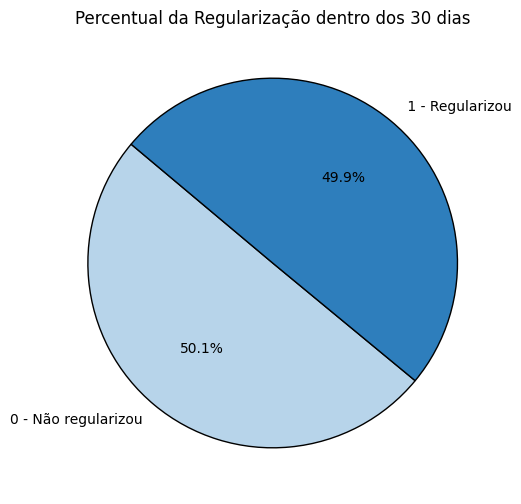

In [17]:
gerar_grafico_pizza(resultado_target.qtd_clientes,
                    ['0 - Não regularizou',' 1 - Regularizou'],
                    "Percentual da Regularização dentro dos 30 dias")

<h4> 2. Em relação ao porte, clientes com MAIOR PORTE tendem a ter MAIOR PROBABIDALIDE DE REGULARIZAR ou não? </h4>

In [18]:
# Padronizando termos
clientes_sem_nulos['porte'] = clientes_sem_nulos['porte'].replace({
    'Média': 'Médio',
    'EPP': 'Empresa de Pequeno Porte',
    'ME': 'Microempresa',
    'Grande': 'Grande'
})

In [19]:
clientes_sem_nulos['porte'].unique()

array(['Médio', 'Empresa de Pequeno Porte', 'Microempresa', 'Grande'],
      dtype=object)

In [20]:
analise_porte = (
    clientes_sem_nulos.groupby('porte')
    .agg(
        qtd_clientes=('id_cliente', 'count'),
        qtd_regularizados=('regularizou_30d', 'sum'),
        taxa_regularizacao=('regularizou_30d', 'mean')
    )
    .reset_index()
)

analise_porte['taxa_regularizacao'] *= 100

analise_porte

,porte,qtd_clientes,qtd_regularizados,taxa_regularizacao
0,Empresa de Pequeno Porte,279,143,51.254480
1,Grande,70,37,52.857143
2,Microempresa,283,142,50.176678
3,Médio,168,77,45.833333


Embora realmente a taxa de regularização seja MAIOR em GRANDE PORTE (52%), as diferenças para os demais é muito pequeno, em torno de 2% a 7%. Note 	Empresa de Pequeno Porte 51%, Grande 52%.

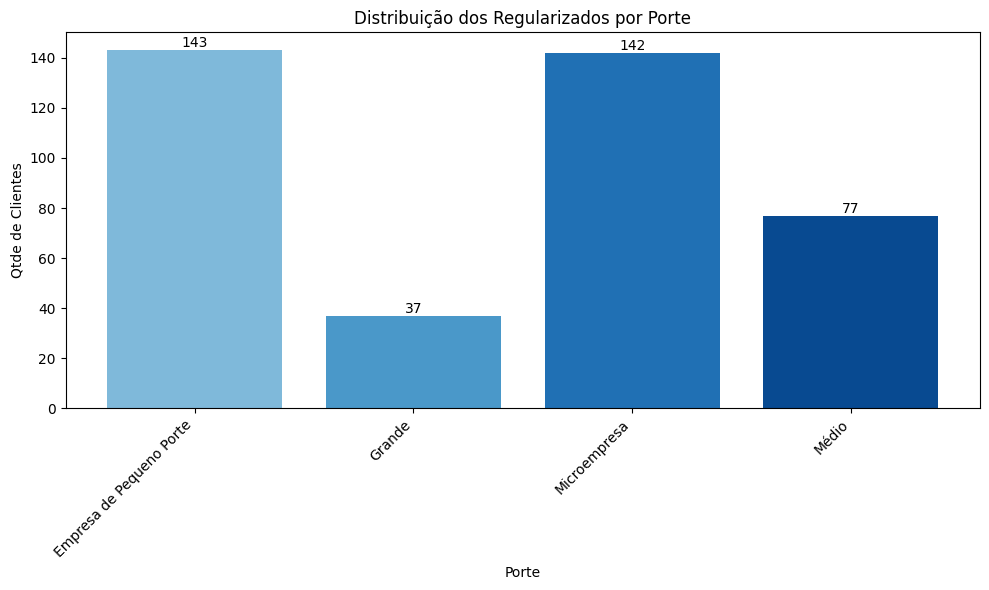

In [21]:
gerar_bar_plot(analise_porte.porte,
               analise_porte.qtd_regularizados,
               "Distribuição dos Regularizados por Porte",
               "Porte",
               "Qtde de Clientes")

<h4> 3. Como está a taxa de regularização por SETOR? </h4>

In [22]:
clientes_sem_nulos['setor'].unique()

array(['Serviços', 'Tecnologia', 'Comércio', 'Agronegócio', 'Indústria',
       'Construção'], dtype=object)

In [23]:
resultado_setor = (
    clientes_sem_nulos
    .groupby(['setor', 'regularizou_30d'])
    .size()
    .reset_index(name='qtd_clientes')
)

resultado_setor['percentual'] = (
    resultado_setor['qtd_clientes']
    / resultado_setor.groupby('setor')['qtd_clientes'].transform('sum')
    * 100
)

In [24]:
grafico_setor = (
    resultado_setor
    .pivot(
        index='setor',
        columns='regularizou_30d',
        values='percentual'
    )
    .fillna(0)
    .reset_index()
)

grafico_setor.columns = [
    'setor',
    'nao_regularizou',
    'regularizou'
]

In [25]:
resultado_setor

,setor,regularizou_30d,qtd_clientes,percentual
0,Agronegócio,0,40,51.282051
1,Agronegócio,1,38,48.717949
2,Comércio,0,95,49.222798
3,Comércio,1,98,50.777202
4,Construção,0,35,42.682927
5,Construção,1,47,57.317073
6,Indústria,0,64,48.120301
7,Indústria,1,69,51.879699
8,Serviços,0,119,52.654867
9,Serviços,1,107,47.345133


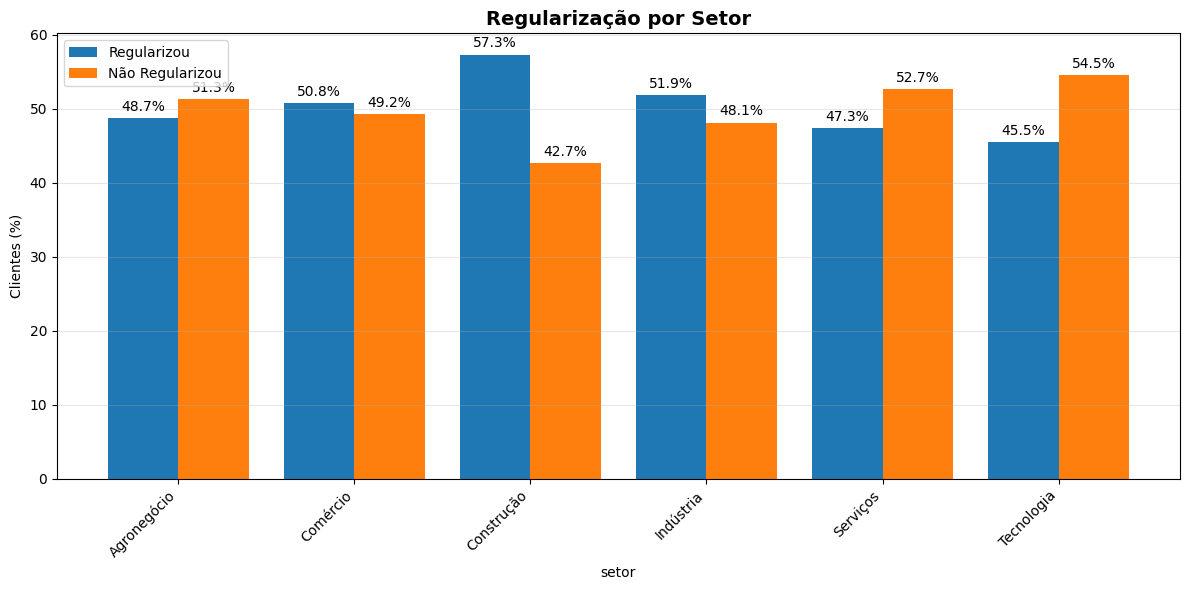

In [26]:
plot_barras_duplas(
    df=grafico_setor,
    coluna_categoria='setor',
    coluna_valor_1='regularizou',
    coluna_valor_2='nao_regularizou',
    nome_valor_1='Regularizou',
    nome_valor_2='Não Regularizou',
    titulo='Regularização por Setor',
    ylabel='Clientes (%)'
)

Curiosamente note que o discrepante maior foi o SETOR DE CONSTRUÇÃO 15% DE DIFERENÇA (42% não regularizou, 57% regularizou). Outro que chama atenção foi o setor de tecnologia com diferença de 9%. Pq?

In [27]:
setor_maior = grafico_setor.loc[
    grafico_setor['regularizou'].idxmax(), 'setor'
]

setor_menor = grafico_setor.loc[
    grafico_setor['regularizou'].idxmin(), 'setor'
]

In [28]:
print(f"Setor que teve MAIOR REGULARIZAÇÃO {setor_maior}")
print(f"Setor que teve MENOR REGULARIZAÇÃO {setor_menor}")

Setor que teve MAIOR REGULARIZAÇÃO Construção
Setor que teve MENOR REGULARIZAÇÃO Tecnologia


<h4> 4. Qual canal é mais utilizado pelos clientes que regularizaram?
Qual canal é mais utilizado pelos clientes que não regularizaram?
Qual é a taxa de regularização dentro de cada canal? </h4>

In [29]:
# 1. Canal de atendimento dos clientes que regularizaram vs. não regularizaram
resultado_canal = (
    clientes_sem_nulos
    .groupby(['canal_preferencial', 'regularizou_30d'])
    .size()
    .reset_index(name='qtd_clientes')
)

resultado_canal['percentual'] = (
    resultado_canal['qtd_clientes']
    / resultado_canal.groupby('regularizou_30d')['qtd_clientes'].transform('sum')
    * 100
)

resultado_canal

,canal_preferencial,regularizou_30d,qtd_clientes,percentual
0,Desconhecido,0,15,3.740648
1,Desconhecido,1,9,2.255639
2,email,0,101,25.187032
3,email,1,95,23.809524
4,portal,0,62,15.461347
5,portal,1,61,15.288221
6,telefone,0,93,23.192020
7,telefone,1,90,22.556391
8,whatsapp,0,130,32.418953
9,whatsapp,1,144,36.090226


In [30]:
# Percentual de regularização por CANAL
taxa_regularizacao_canal = (
    clientes_sem_nulos
    .groupby('canal_preferencial')['regularizou_30d']
    .agg(
        qtd_clientes='count',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

taxa_regularizacao_canal['taxa_regularizacao'] *= 100

taxa_regularizacao_canal = (
    taxa_regularizacao_canal
    .sort_values('taxa_regularizacao', ascending=False)
)

taxa_regularizacao_canal

,canal_preferencial,qtd_clientes,taxa_regularizacao
4,whatsapp,274,52.554745
2,portal,123,49.593496
3,telefone,183,49.180328
1,email,196,48.469388
0,Desconhecido,24,37.500000


In [31]:
grafico_canal = (
    resultado_canal
    .pivot(
        index='canal_preferencial',
        columns='regularizou_30d',
        values='percentual'
    )
    .fillna(0)
    .reset_index()
)

grafico_canal.columns = [
    'canal_preferencial',
    'nao_regularizou',
    'regularizou'
]

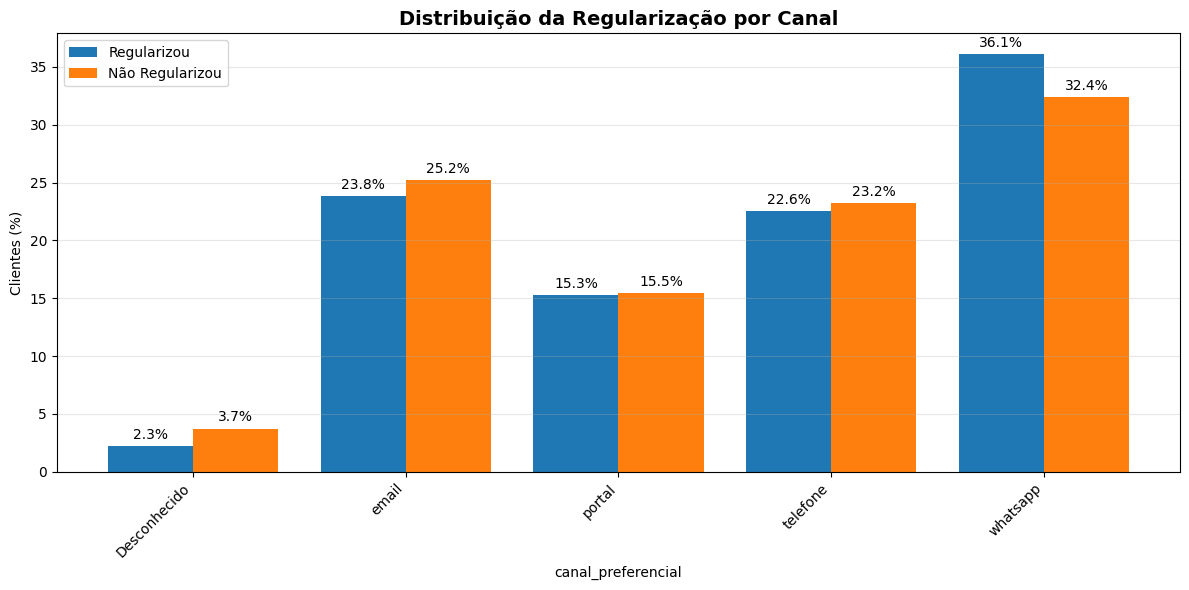

In [32]:
plot_barras_duplas(
    df=grafico_canal,
    coluna_categoria='canal_preferencial',
    coluna_valor_1='regularizou',
    coluna_valor_2='nao_regularizou',
    nome_valor_1='Regularizou',
    nome_valor_2='Não Regularizou',
    titulo='Distribuição da Regularização por Canal',
    ylabel='Clientes (%)'
)

O CANAL PREFERENCIAL É WHATSAP com 36% REGULARIZAÇÃO, 32% NÃO REGULARIZAÇÃO. Note que em relação aos demais canais de atendimentos, a diferença entre regularização e não regularização é minima (1-2%). Parece que o Whatsapp tem se mostrado um bom canal para REGULARIZAÇÃO POR ALGUM MOTIVO, talvez alguma assistente autônomo ou facilidade para o usuário. Cabe investigar. O portal é o canal MENOS USADO.

In [33]:
clientes_sem_nulos.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

<h4> 5. Como está a taxa de regularização por risco setorial? </h4>

In [34]:
# Relembrando os valores de riscos setoriais
clientes_sem_nulos['risco_setorial'].value_counts()

risco_setorial
medio           365
baixo           265
alto            130
Desconhecido     40
Name: count, dtype: int64

In [35]:
taxa_risco_setorial = (
    clientes_sem_nulos
    .groupby('risco_setorial')['regularizou_30d']
    .agg(
        qtd_clientes='count',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

taxa_risco_setorial['taxa_regularizacao'] *= 100

taxa_risco_setorial = taxa_risco_setorial.sort_values(
    'taxa_regularizacao',
    ascending=False
)

In [36]:
taxa_risco_setorial

,risco_setorial,qtd_clientes,taxa_regularizacao
2,baixo,265,52.830189
0,Desconhecido,40,52.500000
3,medio,365,51.506849
1,alto,130,38.461538


O que tem a MENOR TAXA DE REGULARIZAÇÃO É NO RISCO SETORIAL ALTO: 38%. OU SEJA: realmente o risco setorial tem um impacto na taxa de regularização (indicando possível não regularização dentro dos próximos 30 dias).

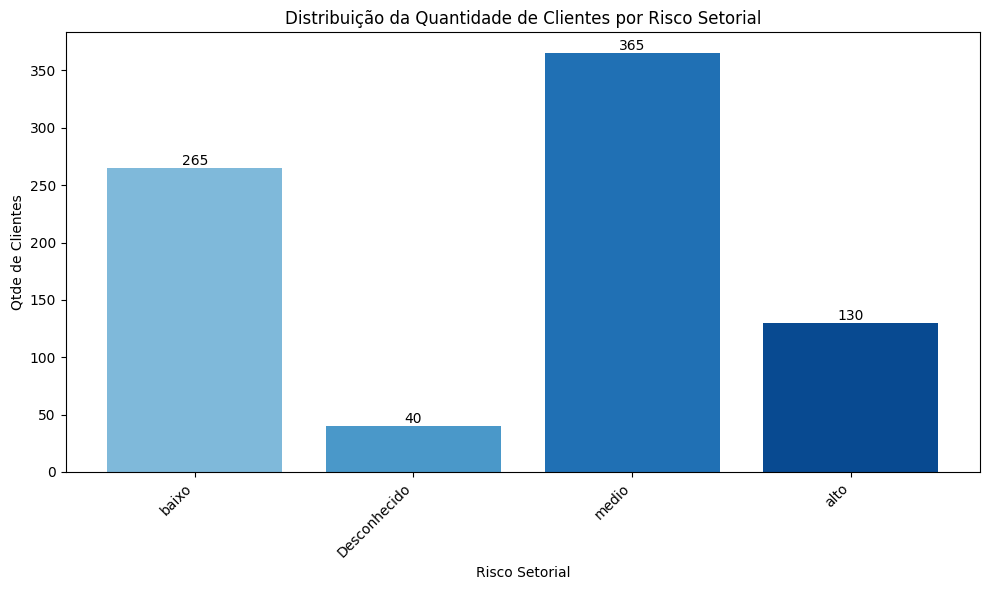

In [37]:
# Perceba que quase nào usam o portal, 15%
gerar_bar_plot(taxa_risco_setorial.risco_setorial,
               taxa_risco_setorial.qtd_clientes,
               "Distribuição da Quantidade de Clientes por Risco Setorial",
               "Risco Setorial",
               "Qtde de Clientes")

<h4> 6. Como está a taxa de regularização por UF? De modo a descobrir o ESTADO que possui a MAIOR e MENOR TAXA DE REGULARIZAÇÃO. </h4>

In [38]:
taxa_regularizacao_uf = (
    clientes_sem_nulos
    .groupby('uf')['regularizou_30d']
    .agg(
        qtd_clientes='count',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

taxa_regularizacao_uf['taxa_regularizacao'] *= 100

taxa_regularizacao_uf = (
    taxa_regularizacao_uf
    .sort_values('taxa_regularizacao', ascending=False)
)

taxa_regularizacao_uf

,uf,qtd_clientes,taxa_regularizacao
6,RS,46,65.217391
1,GO,28,60.714286
3,PE,28,60.714286
7,SC,58,53.448276
5,RJ,113,50.442478
2,MG,108,48.148148
8,SP,325,47.076923
4,PR,66,46.969697
0,BA,28,39.285714


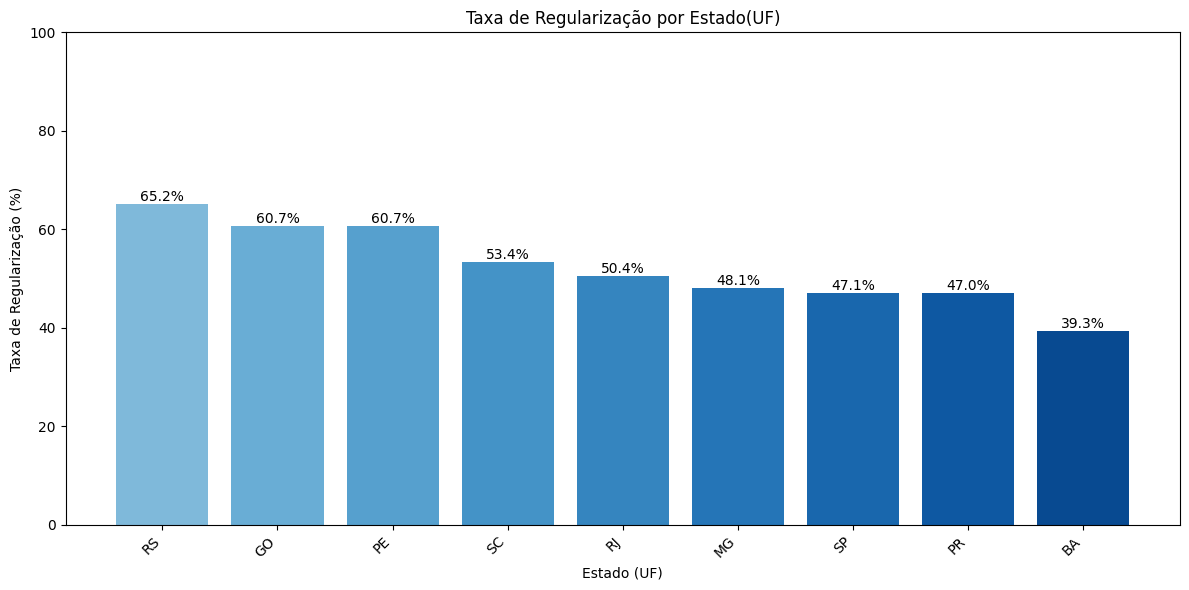

In [39]:
gerar_bar_plot_percentual(
    x=taxa_regularizacao_uf['uf'],
    y=taxa_regularizacao_uf['taxa_regularizacao'],
    titulo='Taxa de Regularização por Estado(UF)',
    xlabel='Estado (UF)',
    ylabel='Taxa de Regularização (%)'
)

A MAIOR TAXA DE REGULARIZAÇÃO está ocorrendo no RS e a MENOR no estado de BA. Cabe investigar.

<h4> 7. Analisando a PROMESSA DE PAGAMENTO NOS ÚLTIMOS 30 DIAS. Clientes que apresentaram uma PROMESSA DE PAGAMENTO NOS ÚLTIMOS 30 DIAS, DE FATO APRESENTARAM MAIOR PROPENSÃO A REGULARIZAÇÃO OU NÃO?  </h4>

In [40]:
# Relembrando os valores da PROMESSA DE PAGAMENTO
clientes_sem_nulos['promessa_pagamento_ult_30d'].value_counts()

promessa_pagamento_ult_30d
0    548
1    252
Name: count, dtype: int64

In [41]:
# Taxa de regularização por PROMESSA
resultado_promessa['teve_promessa'] = (
    resultado_promessa['promessa_pagamento_ult_30d']
    .map({
        0: 'Não apresentou promessa',
        1: 'Apresentou promessa'
    })
)

resultado_promessa

NameError: name 'resultado_promessa' is not defined

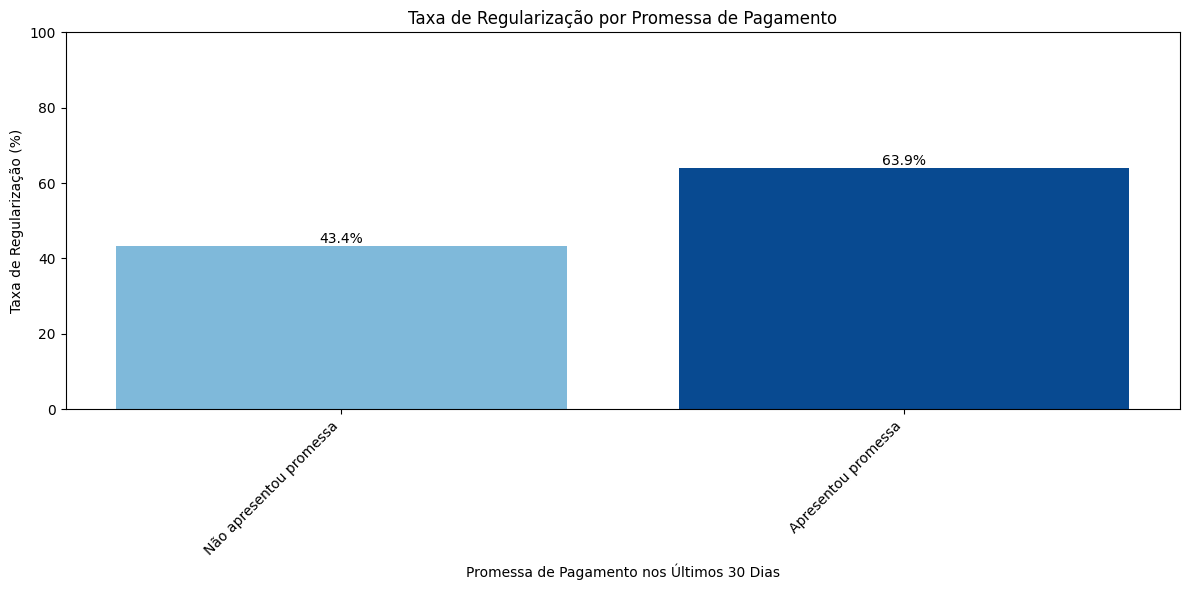

In [ ]:
gerar_bar_plot_percentual(
    x=resultado_promessa['teve_promessa'],
    y=resultado_promessa['taxa_regularizacao'],
    titulo='Taxa de Regularização por Promessa de Pagamento',
    xlabel='Promessa de Pagamento nos Últimos 30 Dias',
    ylabel='Taxa de Regularização (%)'
)

In [ ]:
taxa_com_promessa = resultado_promessa.loc[
    resultado_promessa['promessa_pagamento_ult_30d'] == 1,
    'taxa_regularizacao'
].iloc[0]

taxa_sem_promessa = resultado_promessa.loc[
    resultado_promessa['promessa_pagamento_ult_30d'] == 0,
    'taxa_regularizacao'
].iloc[0]

diferenca_pp = taxa_com_promessa - taxa_sem_promessa

print(f'Taxa com promessa: {taxa_com_promessa:.1f}%')
print(f'Taxa sem promessa: {taxa_sem_promessa:.1f}%')
print(f'Diferença: {diferenca_pp:.1f} p.p.')

Taxa com promessa: 63.9%
Taxa sem promessa: 43.4%
Diferença: 20.5 p.p.


O resultado indica que realmente os que apresentaram uma PROMESSA DE PAGAMENTOS NOS ÚLTIMOS 30 DIAS, APRESENTARAM UMA REGULARIZAÇÃO NOS PRÓXIMOS 30 DIAS, OU SEJA, NÃO FOI APENAS DA BOCA PARA FORA. 63%. EM OUTRAS PALAVRAS A PROMESSA TEVE O IMPACTO DE 20%. Importante ressaltar que o fato de indicar uma PROMESSA não necessariamente irá regularizar (causalidade), podem haver outros fatores que contribuiram para a regularização, cabe um estudo mais aprofundado.

<h4> 8. Será que os DIAS DE ATRASO estão influenciando na regularização dentro dos próximos 30 dias ou não? Responderemos: Quanto maior o atraso, menor a capacidade de regularização nos próximos 30 dias? </h4>

In [ ]:
# Relembrando os Valores de dias de atraso.
clientes_sem_nulos['dias_atraso'].describe()

count    800.000000
mean      45.017500
std       32.675898
min        1.000000
25%       21.000000
50%       38.000000
75%       60.000000
max      180.000000
Name: dias_atraso, dtype: float64

In [ ]:
clientes_sem_nulos['faixa_atraso'] = pd.cut(
    clientes_sem_nulos['dias_atraso'],
    bins=[-1, 0, 30, 60, 90, 180, float('inf')],
    labels=[
        'Sem atraso',
        '1-30 dias',
        '31-60 dias',
        '61-90 dias',
        '91-180 dias',
        '181+ dias'
    ]
)

In [ ]:
analise_atraso = (
    clientes_sem_nulos.groupby('faixa_atraso', observed=True)
    .agg(
        qtd_clientes=('id_cliente', 'count'),
        taxa_regularizacao=('regularizou_30d', 'mean')
    )
    .reset_index()
)

analise_atraso['taxa_regularizacao'] *= 100

analise_atraso

,faixa_atraso,qtd_clientes,taxa_regularizacao
0,1-30 dias,310,67.096774
1,31-60 dias,293,49.829352
2,61-90 dias,117,29.914530
3,91-180 dias,80,12.500000


De fato QUANTO MAIOR O ATRASO, menor a capacidade de regularização nos próximos 30 dias. Os que estão regularizando mais tem entre 1 - 60 dias de atraso, provavelmente devido a juros ou outros eventos. Percebe que atrasos maiores 91-180 dias (6 meses) a taxa de regularização dentro do próximo 30 dias é bem pequeno.

<h4> 9. Utilização do LIMITE PCT. Os clientes que não regularizaram, como está a utilização do limite? [utilizacao_limite_pct] x [target:regularizou_30d] </h4>

Clientes com maior utilização do limite apresentam maior ou menor taxa de regularização?

In [ ]:
# Relembrando os valores
clientes_sem_nulos['utilizacao_limite_pct'].describe()

count    800.000000
mean       0.501349
std        0.176692
min        0.020200
25%        0.383775
50%        0.481650
75%        0.601025
max        1.101300
Name: utilizacao_limite_pct, dtype: float64

In [ ]:
clientes_sem_nulos['faixa_utilizacao_limite_pct'] = pd.cut(
    clientes_sem_nulos['utilizacao_limite_pct'],
    bins=[0, 0.25, 0.50, 0.75, 1.00, float('inf')],
    labels=[
        '0-25%',
        '25-50%',
        '50-75%',
        '75-100%',
        'Acima de 100%'
    ]
)

In [ ]:
# Conferindo os valores e faixas
clientes_sem_nulos[['faixa_utilizacao_limite_pct','utilizacao_limite_pct']].sample(5)

,faixa_utilizacao_limite_pct,utilizacao_limite_pct
727,50-75%,0.7473
413,25-50%,0.4503
653,50-75%,0.5081
591,25-50%,0.4238
81,50-75%,0.5526


In [ ]:
analise_utilizacao_limite_pct = (
    clientes_sem_nulos.groupby('faixa_utilizacao_limite_pct', observed=True)
    .agg(
        qtd_clientes=('id_cliente', 'count'),
        taxa_regularizacao=('regularizou_30d', 'mean')
    )
    .reset_index()
)

analise_utilizacao_limite_pct['taxa_regularizacao'] *= 100

In [ ]:
analise_utilizacao_limite_pct

,faixa_utilizacao_limite_pct,qtd_clientes,taxa_regularizacao
0,0-25%,44,54.545455
1,25-50%,390,50.256410
2,50-75%,292,50.684932
3,75-100%,68,42.647059
4,Acima de 100%,6,33.333333


Quanto maior a utilização do limite → menor a taxa de regularização. Veja a tendência no gráfico, quanto maior a utilização do limite PCT, menor tende a ser a regularização nos próximos 30 dias. Note que isso é uma influência, não uma causalidade.

Perceba que a utilização do limite pct não influencia tanto na regularização dentro dos próximos 30 dias. Observe que clientes que usaram os limites entre 0 - 75% estão com uma taxa de regularização de 50% a mais. Note ainda que usar o limite acima de 75% ai sim reduz significamente a taxa de regularização dentro dos próximos dias. Investigar: talvez os juros altos e rotativos desse produto dificultam a regularização?

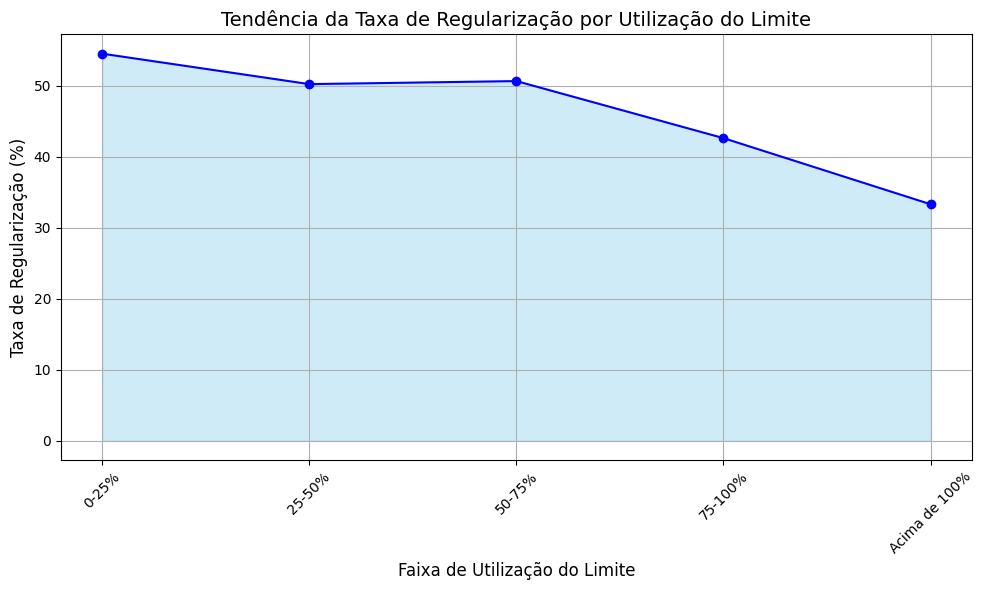

In [ ]:
gerar_grafico_linhas(
    eixo_tempo=analise_utilizacao_limite_pct['faixa_utilizacao_limite_pct'],
    eixo_valores=analise_utilizacao_limite_pct['taxa_regularizacao'],
    title='Tendência da Taxa de Regularização por Utilização do Limite',
    xlabel='Faixa de Utilização do Limite',
    ylabel='Taxa de Regularização (%)'
)

In [ ]:
clientes_sem_nulos.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia', 'faixa_atraso',
       'faixa_utilizacao_limite_pct'],
      dtype='object')

<h4> 10. [qtd_parcelas_vencidas] e [TARGET] Será que quanto PARCELAS VENCIDAS tem o CLIENTE, MENOR A PROBABILIDADE DE REGULARIZAÇÃO dentro dos próximos 30 dias? Ou ao contrário? Em outras palavras: a medida que aumenta a quantidade de parcelas vencidas, a taxa de regularização nos próximos 30 dias aumenta ou diminui?</h4>

In [ ]:
# Relembrando valores
clientes_sem_nulos['qtd_parcelas_vencidas'].describe()

count    800.000000
mean       2.057500
std        1.199371
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: qtd_parcelas_vencidas, dtype: float64

In [ ]:
resultado_parcelas = (
    clientes_sem_nulos
    .groupby('qtd_parcelas_vencidas')['regularizou_30d']
    .agg(
        qtd_clientes='count',
        qtd_regularizou='sum',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

resultado_parcelas['taxa_regularizacao'] *= 100

resultado_parcelas = resultado_parcelas.sort_values(
    'qtd_parcelas_vencidas'
)

resultado_parcelas

,qtd_parcelas_vencidas,qtd_clientes,qtd_regularizou,taxa_regularizacao
0,1,331,204,61.631420
1,2,241,125,51.867220
2,3,134,52,38.805970
3,4,53,13,24.528302
4,5,31,5,16.129032
5,6,6,0,0.000000
6,7,4,0,0.000000


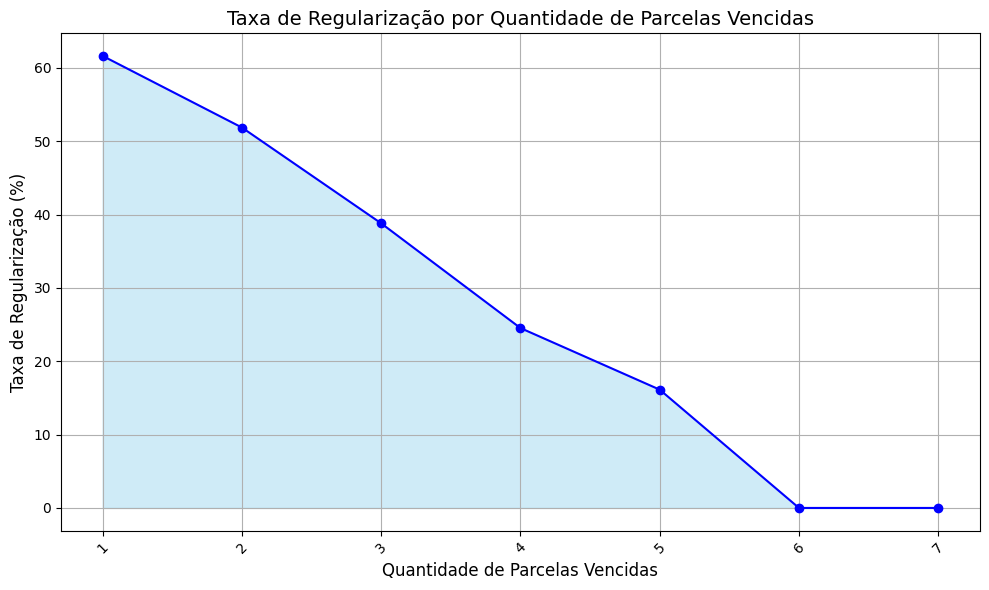

In [ ]:
gerar_grafico_linhas(
    eixo_tempo=resultado_parcelas['qtd_parcelas_vencidas'],
    eixo_valores=resultado_parcelas['taxa_regularizacao'],
    title='Taxa de Regularização por Quantidade de Parcelas Vencidas',
    xlabel='Quantidade de Parcelas Vencidas',
    ylabel='Taxa de Regularização (%)'
)

FATO: quanto maior a quantidade de parcelas vencidas, menor é a taxa de regularização dentro dos próximos 30 dias. Repare que reduz bem significamente. A partir de 5 parcelas vencidas, a taxa de regularização é muito baixa, 16%. Temos uma correlação fraca.

In [ ]:
correlacao_spearman = (
    clientes_sem_nulos[
        ['qtd_parcelas_vencidas', 'regularizou_30d']
    ]
    .corr(method='spearman')
    .loc['qtd_parcelas_vencidas', 'regularizou_30d']
)

print(f'Correlação de Spearman: {correlacao_spearman:.3f}')
# relação negativa -0.2

Correlação de Spearman: -0.260


<h4>11. Será que a taxa de regularização muda considerando a quantidade de parcelas vencidas e o porte da empresa? Em outras palavras, a taxa de regularização diminui conforme aumenta a quantidade de parcelas vencidas, independentemente do porte da empresa?</h4>

In [ ]:
resultado_parcelas_porte = (
    clientes_sem_nulos
    .groupby(['porte', 'qtd_parcelas_vencidas'])['regularizou_30d']
    .agg(
        qtd_clientes='count',
        qtd_regularizou='sum',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

resultado_parcelas_porte['taxa_regularizacao'] *= 100

resultado_parcelas_porte = (
    resultado_parcelas_porte
    .sort_values(['porte', 'qtd_parcelas_vencidas'])
)

resultado_parcelas_porte

,porte,qtd_parcelas_vencidas,qtd_clientes,qtd_regularizou,taxa_regularizacao
0,Empresa de Pequeno Porte,1,121,75,61.983471
1,Empresa de Pequeno Porte,2,87,43,49.425287
2,Empresa de Pequeno Porte,3,48,23,47.916667
3,Empresa de Pequeno Porte,4,12,2,16.666667
4,Empresa de Pequeno Porte,5,9,0,0.000000
5,Empresa de Pequeno Porte,7,2,0,0.000000
6,Grande,1,28,19,67.857143
7,Grande,2,27,15,55.555556
8,Grande,3,8,2,25.000000
9,Grande,4,6,1,16.666667


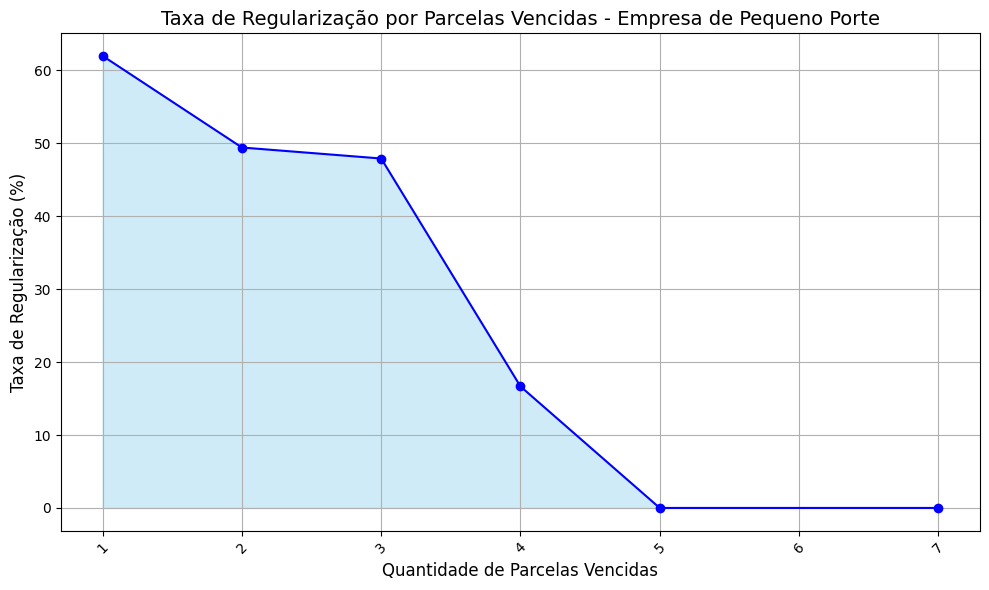

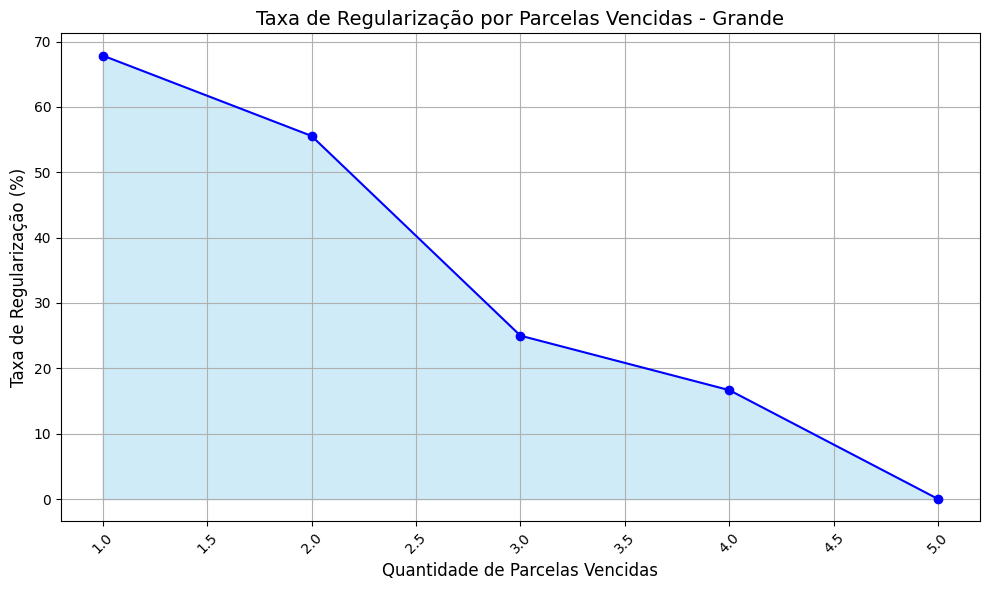

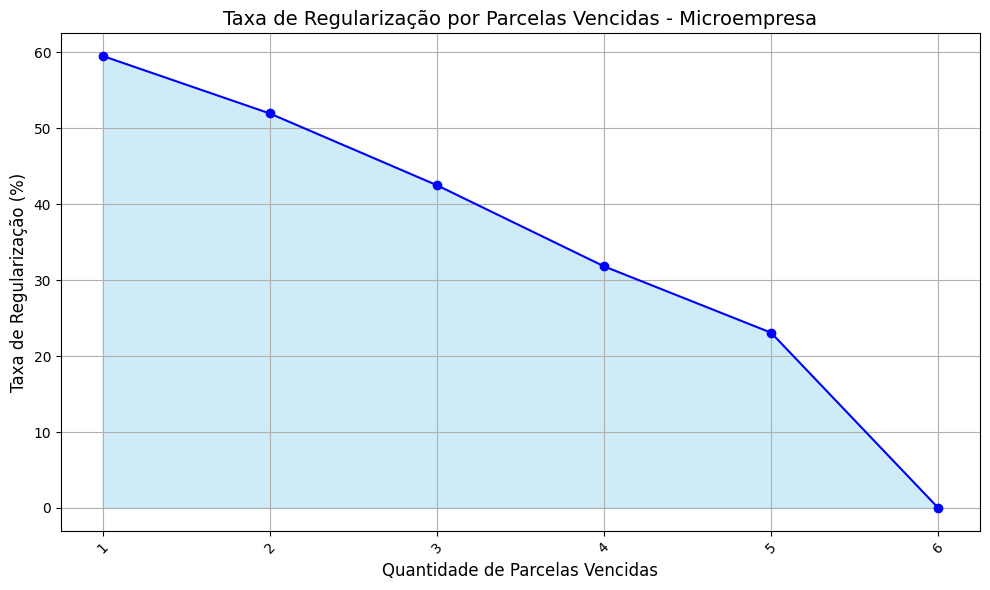

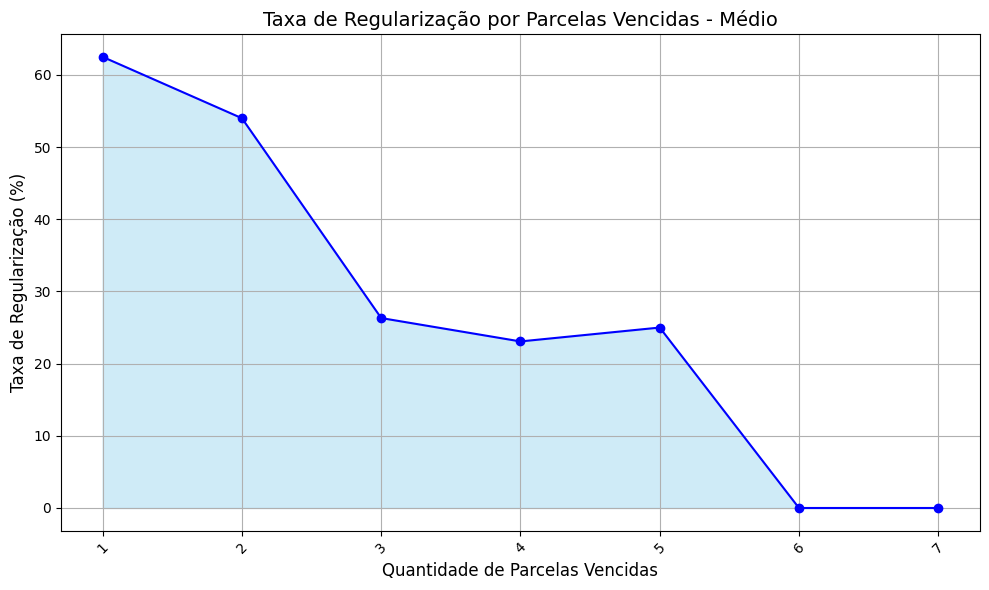

In [ ]:
for porte in resultado_parcelas_porte['porte'].unique():

    dados_porte = resultado_parcelas_porte[
        resultado_parcelas_porte['porte'] == porte
    ]

    gerar_grafico_linhas(
        eixo_tempo=dados_porte['qtd_parcelas_vencidas'],
        eixo_valores=dados_porte['taxa_regularizacao'],
        title=f'Taxa de Regularização por Parcelas Vencidas - {porte}',
        xlabel='Quantidade de Parcelas Vencidas',
        ylabel='Taxa de Regularização (%)'
    )

O comportamento se mantém igual, indepedemente do porte da empresa. Conforme aumenta a quantidade de parcelas, menor é a taxa de regularização dentro dos próximos 30 dias. Curiosidade: a empresa de médio porte oferece uma maior da taxa de regularização com 5 parcelas atradas do que 4, talvez alguma desconto ou promoção aqui.

<h4> 12. Seguindo o mesmo raciocínio: será quanto maior os dias de atrasos, menor tende a ser a regularização dentro dos próximos 30 dias ou não? </h4>

In [42]:
# Conferindo os valores
clientes_sem_nulos['dias_atraso'].describe()

count    800.000000
mean      45.017500
std       32.675898
min        1.000000
25%       21.000000
50%       38.000000
75%       60.000000
max      180.000000
Name: dias_atraso, dtype: float64

In [43]:
# 1. Criando faixa de dias de atraso
clientes_sem_nulos['faixa_dias_atraso'] = pd.cut(
    clientes_sem_nulos['dias_atraso'],
    bins=[-1, 30, 60, 90, 180, float('inf')],
    labels=[
        'Até 30 dias',
        '31 a 60 dias',
        '61 a 90 dias',
        '91 a 180 dias',
        'Acima de 180 dias'
    ]
)

In [44]:
clientes_sem_nulos[['faixa_dias_atraso','dias_atraso']].sample(5)

,faixa_dias_atraso,dias_atraso
770,Até 30 dias,20
765,31 a 60 dias,55
380,Até 30 dias,26
457,Até 30 dias,10
56,31 a 60 dias,33


In [45]:
# Calculando a taxa de regularização
resultado_atraso = (
    clientes_sem_nulos
    .groupby('faixa_dias_atraso', observed=True)['regularizou_30d']
    .agg(
        qtd_clientes='count',
        qtd_regularizou='sum',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

resultado_atraso['taxa_regularizacao'] *= 100

resultado_atraso

,faixa_dias_atraso,qtd_clientes,qtd_regularizou,taxa_regularizacao
0,Até 30 dias,310,208,67.096774
1,31 a 60 dias,293,146,49.829352
2,61 a 90 dias,117,35,29.914530
3,91 a 180 dias,80,10,12.500000


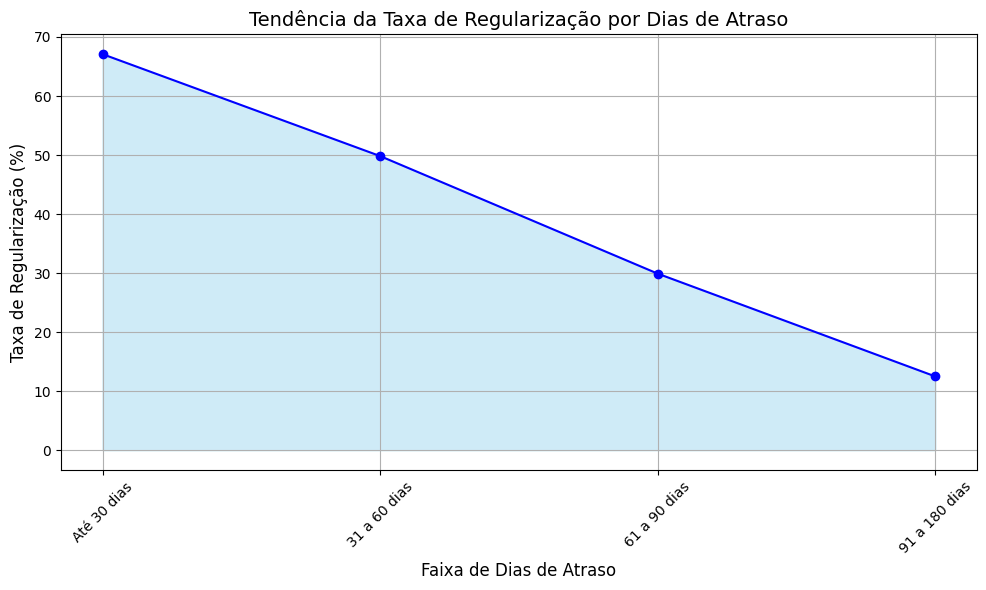

In [46]:
# Visualizando a tendência
gerar_grafico_linhas(
    eixo_tempo=resultado_atraso['faixa_dias_atraso'],
    eixo_valores=resultado_atraso['taxa_regularizacao'],
    title='Tendência da Taxa de Regularização por Dias de Atraso',
    xlabel='Faixa de Dias de Atraso',
    ylabel='Taxa de Regularização (%)'
)

In [48]:
# Calculando a relação
correlacao_spearman = (
    clientes_sem_nulos[
        ['dias_atraso', 'regularizou_30d']
    ]
    .corr(method='spearman')
    .loc['dias_atraso', 'regularizou_30d']
)

print(f'Correlação de Spearman: {correlacao_spearman:.3f}')

Correlação de Spearman: -0.358


Existem uma tendência fraca negativa entre ambos, ou seja, quanto maior a quantidade de dias em atraso MENOR é a taxa de regularização dentro dos próximos 30 dias.

<h4> 13. Análise de Correlações entre [TARGET] e [N VARIÁVEIS] </h4>

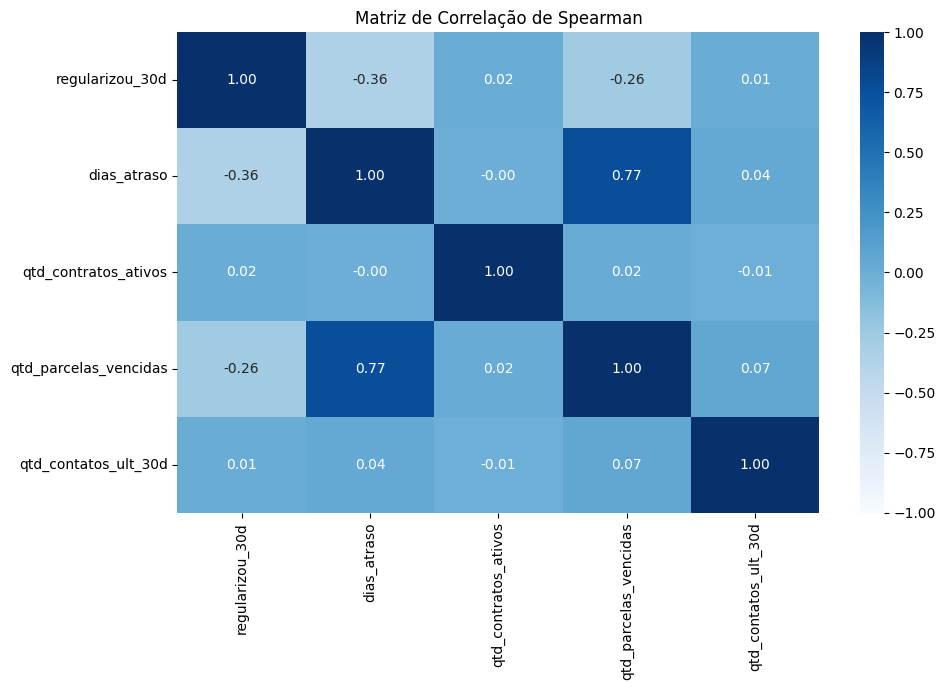

In [56]:
variaveis = [
    'regularizou_30d',
    'dias_atraso',
    'qtd_contratos_ativos',
    'qtd_parcelas_vencidas',
    'qtd_contatos_ult_30d'
]

correlacoes = (
    clientes_sem_nulos[variaveis]
    .corr(method='spearman')
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacoes,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlação de Spearman')
plt.tight_layout()
plt.show()

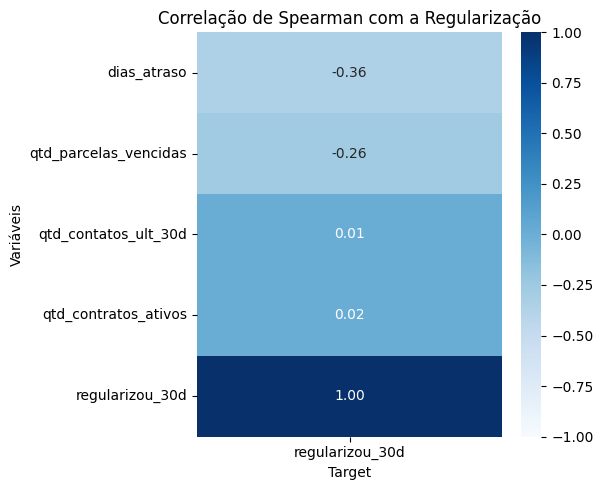

In [57]:
# Mostrando somente as candidatas
variaveis = [
    'dias_atraso',
    'qtd_contratos_ativos',
    'qtd_parcelas_vencidas',
    'qtd_contatos_ult_30d',
    'regularizou_30d'
]

correlacao_target = (
    clientes_sem_nulos[variaveis]
    .corr(method='spearman')[['regularizou_30d']]
    .sort_values('regularizou_30d')
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlacao_target,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlação de Spearman com a Regularização')
plt.xlabel('Target')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

<h4> 14. [Saldo devedor] e [TARGET]. Será que quanto MAIOR O SALDO DEVEDOR menor é a taxa de regularização de pagamento nos próximos 30 dias ou não? </h4>

In [59]:
# Conferindo uma estatística descritiva geral
pd.options.display.float_format = '{:,.2f}'.format
clientes_sem_nulos['saldo_devedor'].describe()

count         800.00
mean       92,212.24
std       188,604.72
min         2,000.00
25%        11,976.34
50%        29,678.24
75%        80,270.04
max     2,100,106.91
Name: saldo_devedor, dtype: float64

In [60]:
# Criando faixas de saldo
clientes_sem_nulos['faixa_saldo_devedor'] = pd.qcut(
    clientes_sem_nulos['saldo_devedor'],
    q=5,
    duplicates='drop'
)

In [61]:
clientes_sem_nulos[['faixa_saldo_devedor','saldo_devedor']].sample(5)

,faixa_saldo_devedor,saldo_devedor
522,"(43717.8, 105301.242]","53,632.32"
228,"(1999.999, 9568.446]","3,024.16"
655,"(9568.446, 21213.048]","16,112.61"
602,"(21213.048, 43717.8]","38,433.75"
175,"(43717.8, 105301.242]","52,141.10"


In [64]:
resultado_saldo = (
    clientes_sem_nulos
    .groupby('faixa_saldo_devedor', observed=True)['regularizou_30d']
    .agg(
        qtd_clientes='count',
        qtd_regularizou='sum',
        taxa_regularizacao='mean'
    )
    .reset_index()
)

resultado_saldo['taxa_regularizacao'] *= 100

resultado_saldo

,faixa_saldo_devedor,qtd_clientes,qtd_regularizou,taxa_regularizacao
0,"(1999.999, 9568.446]",160,82,51.25
1,"(9568.446, 21213.048]",160,88,55.00
2,"(21213.048, 43717.8]",160,81,50.62
3,"(43717.8, 105301.242]",160,78,48.75
4,"(105301.242, 2100106.91]",160,70,43.75


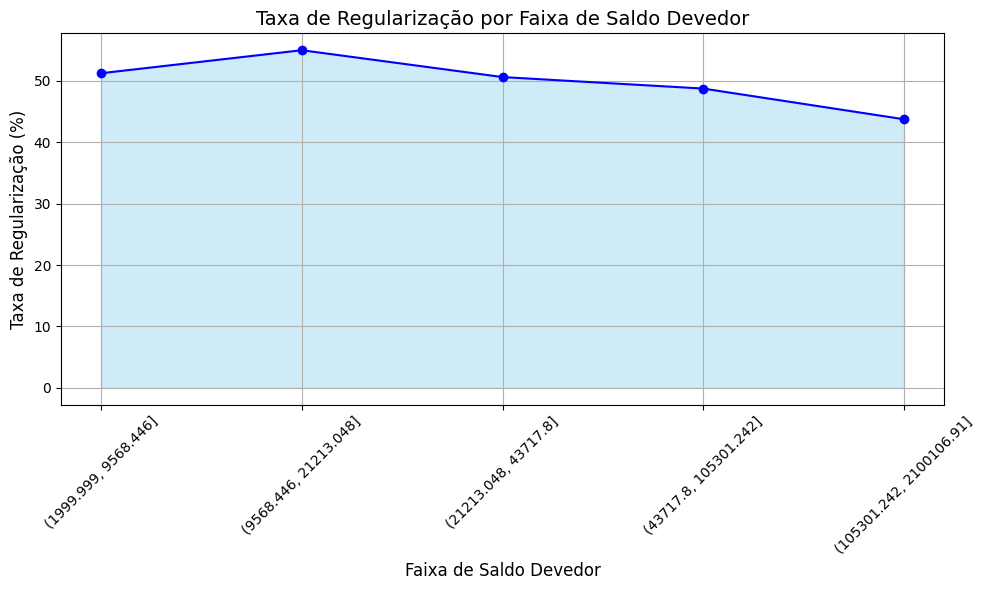

In [67]:
# Visualizando a tendência
resultado_saldo['faixa_saldo_devedor'] = (
    resultado_saldo['faixa_saldo_devedor'].astype(str)
)

gerar_grafico_linhas(
    eixo_tempo=resultado_saldo['faixa_saldo_devedor'],
    eixo_valores=resultado_saldo['taxa_regularizacao'],
    title='Taxa de Regularização por Faixa de Saldo Devedor',
    xlabel='Faixa de Saldo Devedor',
    ylabel='Taxa de Regularização (%)'
)

In [66]:
correlacao_spearman = (
    clientes_sem_nulos[
        ['saldo_devedor', 'regularizou_30d']
    ]
    .corr(method='spearman')
    .loc['saldo_devedor', 'regularizou_30d']
)

print(
    f'Correlação de Spearman: '
    f'{correlacao_spearman:.3f}'
)

Correlação de Spearman: -0.052


-0,052 está muito próximo de zero, portanto existe uma associação negativa muito fraca, praticamente inexistente, entre saldo_devedor e regularizou_30d. Não há evidência de uma relação monotônica relevante entre o saldo devedor e a taxa de regularização nos 30 dias seguintes. Ou seja, não podemos afirmar que clientes com maior saldo devedor tenham menor propensão à regularização com base nessa análise.

<h4> 15. [score_cobranca_atualizado_30d] e [TARGET] -- PENDENTE </h4> 